# Effective Area Tests for fl16y

Extracted from exposure_fl16y.ipynb to keep effective-area checks separate from exposure generation.

In [1]:
%reset -f
%run pylib/tools dark date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from like3.exposure import EffectiveAreaIRF

<h5 style="text-align:right; margin-right:15px"> 2026-04-01 11:44</h5>

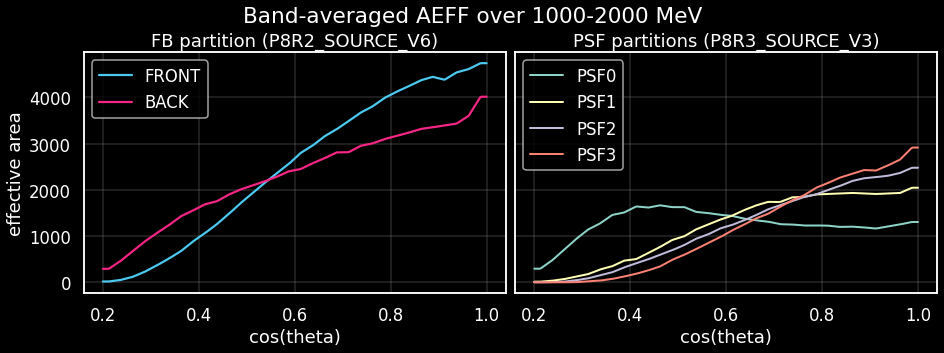

In [2]:
def band_avg_aeff_vs_costh(ea_obj, cth_grid, emin=1000.0, emax=2000.0, component='TOTAL'):
    """Average effective area over an energy interval for each cos(theta)."""
    comp = component.upper()
    if comp not in ('FRONT', 'BACK', 'TOTAL'):
        raise ValueError("component must be one of 'FRONT', 'BACK', 'TOTAL'")

    ecent = np.sqrt(ea_obj.ebins[:-1] * ea_obj.ebins[1:])
    emask = (ecent >= emin) & (ecent <= emax)
    if not np.any(emask):
        raise ValueError(f'No energy bins in range [{emin}, {emax}] MeV')

    euse = ecent[emask]
    out = np.empty_like(cth_grid, dtype=float)
    for i, c in enumerate(cth_grid):
        f, b = ea_obj(euse, c, event_class=-1)
        if comp == 'FRONT':
            out[i] = np.mean(np.asarray(f))
        elif comp == 'BACK':
            out[i] = np.mean(np.asarray(b))
        else:
            out[i] = np.mean(np.asarray(f) + np.asarray(b))
    return out


aeff_path = Path('/home/burnett/wtlike-data/aeff_files')
if not aeff_path.exists():
    raise FileNotFoundError(aeff_path)

cth = np.linspace(0.2, 1.0, 300)
emin, emax = 1000.0, 2000.0

fb_irf = 'P8R2_SOURCE_V6'
psf_irf = 'P8R3_SOURCE_V3'

aeff_curves = {}
fig, (ax_fb, ax_psf) = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True, constrained_layout=True)

try:
    fb = EffectiveAreaIRF(irf=fb_irf, file_path=str(aeff_path), partition='FB')
    for comp, color in [('FRONT', '#4cc9f0'), ('BACK', '#f72585')]:
        y = band_avg_aeff_vs_costh(fb, cth, emin=emin, emax=emax, component=comp)
        aeff_curves[('FB', comp)] = y
        ax_fb.plot(cth, y, lw=2.2, color=color, label=comp)
except Exception as e:
    print(f'Could not load FB partition for {fb_irf}: {e}')

ax_fb.set(
    xlabel='cos(theta)',
    ylabel='effective area',
    title=f'FB partition ({fb_irf})',
)
ax_fb.grid(alpha=0.3)
ax_fb.legend()

psf_partitions = ['PSF0', 'PSF1', 'PSF2', 'PSF3']
psf_available = []
psf_missing = []
for partition in psf_partitions:
    try:
        ea = EffectiveAreaIRF(irf=psf_irf, file_path=str(aeff_path), partition=partition)
        y = band_avg_aeff_vs_costh(ea, cth, emin=emin, emax=emax, component='TOTAL')
        aeff_curves[(partition, 'TOTAL')] = y
        ax_psf.plot(cth, y, lw=2, label=partition)
        psf_available.append(partition)
    except Exception as e:
        psf_missing.append((partition, str(e)))

if psf_missing:
    print('Missing/unavailable PSF partitions:')
    for partition, err in psf_missing:
        print(f'  {partition}: {err}')

ax_psf.set(
    xlabel='cos(theta)',
    title=f'PSF partitions ({psf_irf})',
)
ax_psf.grid(alpha=0.3)
ax_psf.legend()

fig.suptitle(f'Band-averaged AEFF over {emin:.0f}-{emax:.0f} MeV')
plt.show()

In [7]:
df = pd.read_pickle('files/psf_psf_table.pkl')
    

In [10]:
show(df['energy event_type'.split()])

,energy,event_type
0,133.352143,4
1,133.352143,5
2,237.137371,4
3,237.137371,5
4,421.696503,3
5,421.696503,4
6,421.696503,5
7,749.894209,3
8,749.894209,4
9,749.894209,5
